<center>
<h1>IA PAU Data Battle 2026 — Rapport d'approche</h1>
<h3>Système d'alerte météorologique par apprentissage automatique</h3>
</center>

---

Ce notebook constitue le rapport complet de notre approche pour le Data Battle.  
Il décrit la méthodologie, les modèles utilisés, le système d'alerte construit, et compare les performances par rapport au système de référence (alerte fixe de 30 minutes).

## 0. Imports et utilitaires

In [1]:
import pandas as pd
import numpy as np
import joblib
import sys, os
from importlib import reload
from joblib import Parallel, delayed
from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import feature_engineering_function
reload(feature_engineering_function)
from src.feature_engineering_function import build_features

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

In [2]:
# ── Tracker d'énergie (optionnel, nécessite codecarbon) ──────
try:
    from codecarbon import EmissionsTracker

    class EnergyAccumulator:
        def __init__(self):
            self._total_wh = 0.0
            self._tracker  = None
            self._label    = ""
        def start(self, label=""):
            self._label   = label
            self._tracker = EmissionsTracker(log_level="error", save_to_file=False)
            self._tracker.start()
        def stop(self):
            if self._tracker is None: return
            self._tracker.stop()
            wh = self._tracker._total_energy.kWh * 1000
            self._total_wh += wh
            print(f"[{self._label}] {wh:.4f} Wh  |  Total cumulé : {self._total_wh:.4f} Wh")
            self._tracker = None
        def total(self):
            print(f"\n=== Energie totale : {self._total_wh:.4f} Wh  ({self._total_wh/1000:.6f} kWh) ===")

    nrj = EnergyAccumulator()
    print("Tracker énergie disponible.")
except ImportError:
    class _Noop:
        def start(self, label=""): pass
        def stop(self): pass
        def total(self): print("codecarbon non installé — pip install codecarbon")
    nrj = _Noop()
    print("codecarbon non installé — tracker énergie désactivé.")

Tracker énergie disponible.


---
## 1. Problématique et données

### 1.1 Contexte

L'objectif est de **prédire le risque foudre** à proximité des aéroports afin de déclencher des alertes opérationnelles. Une alerte est émise lorsqu'un risque est détecté, et elle est maintenue pendant une durée déterminée.

Le défi est double :
- **Couvrir** un maximum d'éclairs CG ≤ 20 km (sécurité)  
- **Minimiser** la durée totale des alertes (coût opérationnel)

### 1.2 Système de référence : alerte fixe 30 minutes

Le système opérationnel actuel (**baseline**) est simple :
> Dès qu'un éclair CG est détecté à ≤ 20 km, une alerte est déclenchée pour **30 minutes**.  
> Si un nouvel éclair CG20 survient pendant cette période, l'alerte est **prolongée** de 30 min à partir de ce nouvel éclair.

Ce système garantit une bonne couverture mais génère des **alertes longues et fréquentes**, même lorsque le danger est passé.

### 1.3 Notre approche : modèles prédictifs + seuil optimisé

Nous entraînons des modèles XGBoost pour prédire la probabilité qu'un éclair CG20 survienne dans les prochaines **10, 15 ou 30 minutes** (et dans un rayon de 3 km). Ces probabilités alimentent un **système de décision adaptatif** qui :
- Déclenche une alerte **avant** l'éclair (anticipation)
- Lève l'alerte **plus tôt** si le risque prédit est faible
- Optimise le seuil de décision via **validation croisée temporelle**

---
## 2. Chargement des données

In [3]:
nrj.start("chargement + features")

df_eval_raw = pd.read_csv('data\\segment_alerts_all_airports_eval.csv')
print(f"Jeu eval  : {df_eval_raw.shape[0]:,} lignes, {df_eval_raw.shape[1]} colonnes")
print(f"Aéroports : {sorted(df_eval_raw['airport'].unique())}")
print(f"Période   : {df_eval_raw['date'].min()} → {df_eval_raw['date'].max()}")
df_eval_raw.head(3)

[codecarbon WARNING @ 09:40:09] Multiple instances of codecarbon are allowed to run at the same time.


Jeu eval  : 188,175 lignes, 13 colonnes
Aéroports : ['Ajaccio', 'Bastia', 'Biarritz', 'Nantes', 'Pise']
Période   : 2023-01-08 22:23:16+00:00 → 2025-12-26 01:08:02+00:00


,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,72502,72502,2023-01-08 22:23:16+00:00,9.0451,42.0114,-123.04,0.257,False,22.262351,70.073897,Ajaccio,NaN,NaN
1,72503,72503,2023-01-08 22:25:20+00:00,9.0685,42.0267,-125.94,0.104,False,24.752225,68.784898,Ajaccio,NaN,NaN
2,72504,72504,2023-01-08 22:27:17+00:00,9.1137,42.0227,-84.71,0.054,False,27.937918,72.314880,Ajaccio,NaN,NaN


### 2.1 Description des variables clés

| Variable | Description |
|---|---|
| `date` | Horodatage de l'éclair |
| `airport` | Code OACI de l'aéroport |
| `dist` | Distance à l'aéroport (km) |
| `icloud` | 1 = éclair intra-nuage, 0 = CG (nuage-sol) |
| `time_to_next_cg20` | Temps (s) avant le prochain CG ≤ 20 km (**cible**) |

Total éclairs       : 188,175
Dont CG ≤ 20 km     : 18,010 (9.6%)


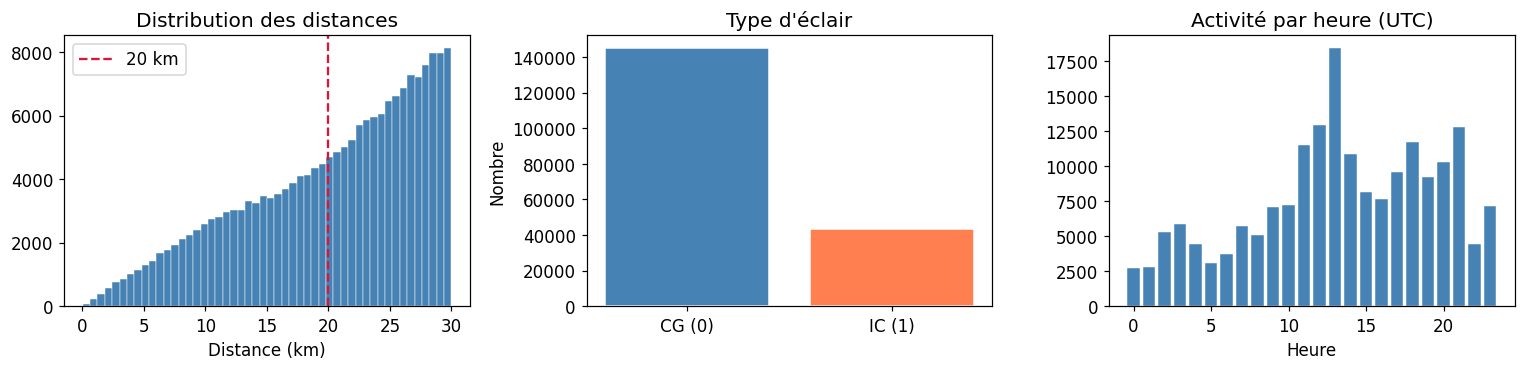

In [25]:
# Statistiques descriptives des variables clés
cg20_eval = (~df_eval_raw['icloud'].astype(bool)) & (df_eval_raw['dist'] <= 20)
print(f"Total éclairs       : {len(df_eval_raw):,}")
print(f"Dont CG ≤ 20 km     : {cg20_eval.sum():,} ({cg20_eval.mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# Distribution des distances
axes[0].hist(df_eval_raw['dist'].clip(0, 100), bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(20, color='crimson', linestyle='--', label='20 km')
axes[0].set_title('Distribution des distances')
axes[0].set_xlabel('Distance (km)')
axes[0].legend()

# Répartition CG vs IC
type_counts = df_eval_raw['icloud'].value_counts()
axes[1].bar(['CG (0)', 'IC (1)'], [type_counts.get(0, 0), type_counts.get(1, 0)],
            color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('Type d\'éclair')
axes[1].set_ylabel('Nombre')

# Activité par heure
df_eval_raw['hour'] = pd.to_datetime(df_eval_raw['date']).dt.hour
hour_counts = df_eval_raw.groupby('hour').size()
axes[2].bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='white', linewidth=0.3)
axes[2].set_title('Activité par heure (UTC)')
axes[2].set_xlabel('Heure')
df_eval_raw.drop('hour',axis=1)
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering

À partir des données brutes, nous construisons des variables temporelles et spatiales qui capturent :

| Famille | Exemples |
|---|---|
| **Distances** | `min_dist_1/5/10min`, `mean_dist_10min`, `delta_dist` |
| **Activité récente** | `log_count_5/10/30min`, `burst_indicator`, `activity_decay` |
| **Type d'éclair** | `cg_20km`, `is_cloud_ground`, `cg_ratio` |
| **Direction & vitesse** | `storm_velocity`, `storm_direction_change`, `azimuth_diff` |
| **Amplitude** | `max_amplitude_10min`, `log_std_amplitude_10min` |
| **Silences** | `silence_30min`, `time_since_last_CG20_2` |
| **Temporel** | `hour`, `month` |

In [26]:
df_eval, VAR1, TARGET1, IDS1, new_dummies1 = build_features(df_eval_raw)
df_eval = df_eval.reset_index(drop=True)
print(f"Features construites : {df_eval.shape[1] - df_eval_raw.shape[1]} nouvelles colonnes")

nrj.stop()

✅ Typage & tri
✅ Variables temporelles
✅ Délais passés + futur strict
✅ Comptages rolling
✅ Comptages par type
✅ Taux d'activité
✅ Variables spatiales & azimut
✅ Variables amplitude
✅ Variables alerte
✅ Dynamique orage
✅ Silence & direction
✅ Centre de masse
✅ Cible créée | 188,175 lignes conservées
Features construites : 97 nouvelles colonnes


---
## 4. Les modèles prédictifs

### 4.1 Architecture

Nous entraînons **4 modèles XGBoost** de classification binaire, chacun ciblant un horizon et un rayon différents :

| Modèle | Cible | Question posée |
|---|---|---|
| `xgb_cg10` | `time_to_next_cg20 > 10 min` | Y aura-t-il un CG20 dans les 10 prochaines minutes ? |
| `xgb_cg15` | `time_to_next_cg20 > 15 min` | Y aura-t-il un CG20 dans les 15 prochaines minutes ? |
| `xgb_cg30` | `time_to_next_cg20 > 30 min` | Y aura-t-il un CG20 dans les 30 prochaines minutes ? |
| `xgb_cg15_3km` | `time_to_next_cg3 > 15 min` | Y aura-t-il un CG à ≤ 3 km dans les 15 prochaines minutes ? |

> **Note :** Les modèles prédisent **P(pas d'éclair dans les X minutes)**.  
> Une probabilité **faible** signifie que le danger est **imminent**.

### 4.2 Entraînement

- Données d'entraînement : `segment_alerts_all_airports_train.csv`
- Validation : stratifiée par aéroport
- Imputation des valeurs manquantes par la médiane
- Hyperparamètres optimisés par recherche bayésienne

In [27]:
nrj.start("chargement modèles + prédictions")

artefacts = joblib.load('models/xgb_cg10_artefacts.pkl')
model_xgb10 = artefacts['model'];  xgb_vars10 = artefacts['vars_to_use'];  imputer10 = artefacts['imputer']

artefacts = joblib.load('models/xgb_cg30_artefacts.pkl')
model_xgb30 = artefacts['model'];  xgb_vars30 = artefacts['vars_to_use']

artefacts = joblib.load('models/xgb_cg15_artefacts.pkl')
model_xgb15 = artefacts['model'];  xgb_vars15 = artefacts['vars_to_use']

artefacts = joblib.load('models/xgb_cg15_3km_artefacts.pkl')
model_xgb15_3 = artefacts['model'];  xgb_vars15_3 = artefacts['vars_to_use'];  imputer15_3 = artefacts['imputer']

print("Modèles chargés.")

VAR = ['min_dist_5min', 'time_since_last_CG20_2', 'log_count_30min', 'amplitude_change',
 'activity_decay', 'time_since_last_intra_cloud2', 'log_cg_count_10min', 'min_dist_1min',
 'cg_20km', 'log_std_amplitude_10min', 'is_cloud_ground', 'log_cg_count_20min',
 'burst_indicator', 'hour', 'storm_direction_change', 'time_since_last_cloud_ground2',
 'std_lat_10min', 'mean_dist_1min', 'dist', 'log_count_5min', 'alert_duration',
 'delta_dist', 'log_ic_count_10min', 'storm_center_distance', 'silence_30min',
 'azimuth_diff', 'max_amplitude_10min', 'std_azimuth_10min', 'storm_spread', 'month',
 'mean_azimuth_1min', 'log_count_20min', 'std_azimuth_1min', 'azimuth',
 'storm_center_velocity', 'log_ic_count_5min', 'max_amplitude_1min', 'storm_velocity',
 'mean_dist_10min', 'storm_center_move', 'mean_azimuth_10min', 'mean_amplitude_1min',
 'cg_ratio', 'rate_trend', 'log_ic_count_20min', 'min_dist_10min', 'azimuth_change',
 'distance_trend', 'mean_dist_5min', 'mean_amplitude_10min', 'std_lon_10min',
 'time_since_last_lightning2', 'log_count_10min', 'log_cg_count_5min',
 'activity_acceleration', 'log_count_1min']

df_eval[VAR] = imputer10.transform(df_eval[VAR])

df_enc      = pd.get_dummies(df_eval[xgb_vars10])
df_eval['probas_10']    = model_xgb10.predict_proba(df_enc)[:, 1]
df_eval['probas_15']    = model_xgb15.predict_proba(df_enc)[:, 1]
df_eval['probas_30']    = model_xgb30.predict_proba(df_enc)[:, 1]

df_enc2     = pd.get_dummies(df_eval[xgb_vars15_3])
df_eval['probas_15_3km'] = 1 - model_xgb15_3.predict_proba(df_enc2)[:, 1]# pour harmoniser

nrj.stop()
print("Probabilités calculées.")
df_eval[['probas_10', 'probas_15', 'probas_30', 'probas_15_3km']].describe().round(3)

Modèles chargés.
[chargement modèles + prédictions] 0.0272 Wh  |  Total cumulé : 0.1193 Wh
Probabilités calculées.


,probas_10,probas_15,probas_30,probas_15_3km
count,188175.000,188175.000,188175.000,188175.000
mean,0.219,0.164,0.124,0.837
std,0.324,0.267,0.251,0.289
min,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.848
50%,0.013,0.007,0.001,0.984
75%,0.383,0.223,0.081,0.998
max,0.999,0.996,1.000,1.000


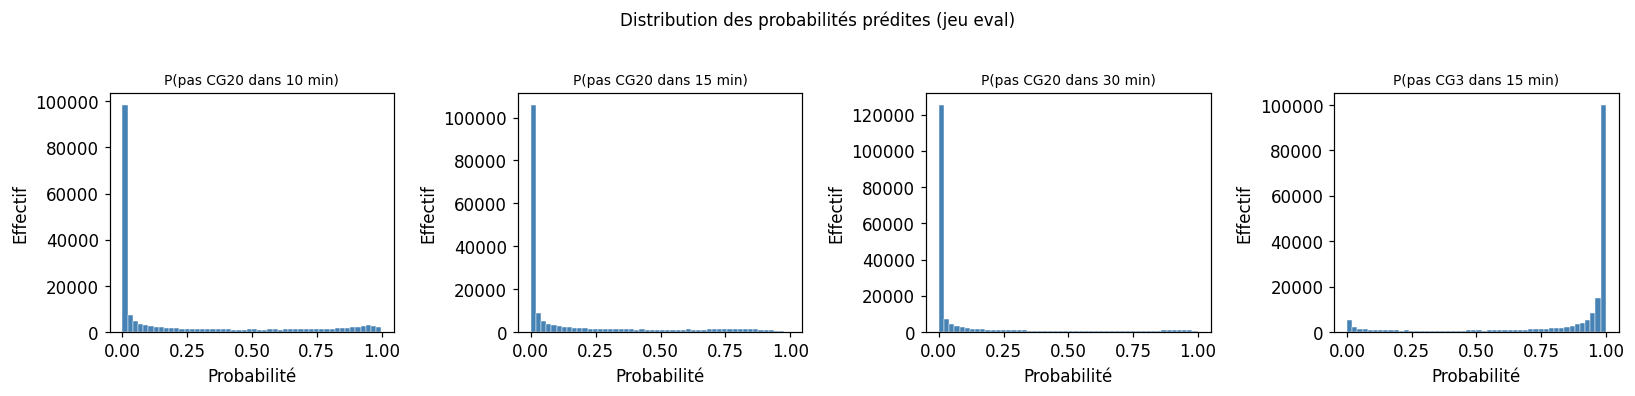

In [7]:
# Distribution des probabilités prédites
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, col, title in zip(axes,
    ['probas_10', 'probas_15', 'probas_30', 'probas_15_3km'],
    ['P(pas CG20 dans 10 min)', 'P(pas CG20 dans 15 min)',
     'P(pas CG20 dans 30 min)', 'P(pas CG3 dans 15 min)']):
    ax.hist(df_eval[col], bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Probabilité')
    ax.set_ylabel('Effectif')
plt.suptitle('Distribution des probabilités prédites (jeu eval)', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

### Performance sur le nouveau jeu

In [28]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             brier_score_loss)
import numpy as np
def evaluate_models(df, models_config=None):
    """
    Évalue les performances de chaque modèle binaire et retourne un DataFrame synthétique.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contenant les colonnes y_* et probas_*.
    models_config : list[dict], optional
        Liste de configs. Par défaut, utilise les 4 modèles standard.
        Chaque dict : {'name': str, 'y_col': str, 'proba_col': str, 'threshold': float}

    Returns
    -------
    pd.DataFrame avec une ligne par modèle et les métriques en colonnes.
    """
    if models_config is None:
        models_config = [
            {'name': 'XGB 10min',      'y_col': 'y_10',    'proba_col': 'probas_10',     'threshold': 0.5},
            {'name': 'XGB 15min',      'y_col': 'y_15',    'proba_col': 'probas_15',     'threshold': 0.5},
            {'name': 'XGB 30min',      'y_col': 'y_30',    'proba_col': 'probas_30',     'threshold': 0.5},
            {'name': 'XGB 15min 3km',  'y_col': 'y_15_3k', 'proba_col': 'probas_15_3km', 'threshold': 0.5},
        ]

    rows = []
    for cfg in models_config:
        name      = cfg['name']
        y_col     = cfg['y_col']
        proba_col = cfg['proba_col']
        threshold = cfg.get('threshold', 0.5)

        # Filtrer les NaN sur y ET probas
        mask = df[y_col].notna() & df[proba_col].notna()
        y_true = df.loc[mask, y_col].astype(int).values
        y_prob = df.loc[mask, proba_col].values
        y_pred = (y_prob >= threshold).astype(int)

        n = len(y_true)
        prevalence = y_true.mean()

        rows.append({
            'Modèle':       name,
            'N':            n,
            'Prévalence':   f'{prevalence:.1%}',
            'Accuracy':     accuracy_score(y_true, y_pred),
            'Precision':    precision_score(y_true, y_pred, zero_division=0),
            'Recall':       recall_score(y_true, y_pred, zero_division=0),
            'F1':           f1_score(y_true, y_pred, zero_division=0),
            'ROC AUC':      roc_auc_score(y_true, y_prob),
            'PR AUC':       average_precision_score(y_true, y_prob),
            'PR':       average_precision_score(y_true, y_prob)/prevalence,
            'Brier':        brier_score_loss(y_true, y_prob),
            'Seuil':        threshold,
        })

    results = pd.DataFrame(rows)

    # Formater les colonnes numériques
    fmt_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC', 'PR AUC', 'Brier']
    for col in fmt_cols:
        results[col] = results[col].map(lambda x: round(x, 4))

    return results

In [29]:
df_eval['y_10'] = df_eval['time_to_next_cg20']>(10 * 60)

df_eval['y_15'] = df_eval['time_to_next_cg20']>(15 * 60)

df_eval['y_30'] = df_eval['time_to_next_cg20']>(30 * 60)

df_eval['y_15_3k'] = df_eval['time_to_next_cg3']>(15 * 60)


In [30]:
# ── Seuil optimal (issu du notebook threshold_cv_optimization) ──

SEUIL_OPTIMAL = 0.62

perf = evaluate_models(df_eval, models_config=[
    {'name': 'XGB 10min',     'y_col': 'y_10',    'proba_col': 'probas_10',     'threshold': SEUIL_OPTIMAL},
    {'name': 'XGB 15min',     'y_col': 'y_15',    'proba_col': 'probas_15',     'threshold': SEUIL_OPTIMAL},
    {'name': 'XGB 30min',     'y_col': 'y_30',    'proba_col': 'probas_30',     'threshold': SEUIL_OPTIMAL},
    {'name': 'XGB 15min 3km', 'y_col': 'y_15_3k', 'proba_col': 'probas_15_3km', 'threshold': SEUIL_OPTIMAL},
])
print(perf.to_string(index=False))

       Modèle      N Prévalence  Accuracy  Precision  Recall     F1  ROC AUC  PR AUC       PR  Brier  Seuil
    XGB 10min 188175      21.7%    0.8593     0.7148  0.5835 0.6425   0.9146  0.7141 3.296231 0.1002   0.62
    XGB 15min 188175      17.9%    0.8730     0.7282  0.4607 0.5644   0.9210  0.6835 3.827096 0.0864   0.62
    XGB 30min 188175      13.0%    0.8882     0.6029  0.4080 0.4866   0.9049  0.5386 4.147485 0.0843   0.62
XGB 15min 3km 188175      81.2%    0.8376     0.8891  0.9140 0.9014   0.8295  0.9502 1.170138 0.1258   0.62


In [ ]:
       Modèle      N Prévalence  Accuracy  Precision  Recall     F1  ROC AUC  PR AUC       PR  Brier  Seuil
    XGB 10min 188175      21.7%    0.8569     0.7186  0.5577 0.6280   0.9138  0.7099 3.276862 0.1004  0.585
    XGB 15min 188175      17.9%    0.8755     0.7127  0.5072 0.5926   0.9211  0.6834 3.826531 0.0863  0.580
    XGB 30min 188175      13.0%    0.8875     0.6030  0.3915 0.4747   0.9050  0.5360 4.127292 0.0841  0.603
XGB 15min 3km 188175      81.2%    0.8391     0.8870  0.9189 0.9027   0.8278  0.9494 1.169152 0.1259  0.591

---
## 5. Logique du système d'alerte

Le système suit un **arbre de décision** appliqué à chaque instant de l'épisode orageux :

```
1. [RÈGLE ABSOLUE] CG ≤ 20 km détecté hors alerte ?
   └── OUI → Alerte immédiate 10 min

2. Fin d'alerte en cours ?
   └── Dernier éclair pendant l'alerte avait p10 ≤ seuil ?
       └── OUI → Prolongation 10 min depuis la date de cet eclair
       └── NON → Fin d'alerte

3. p30 > seuil ET p15 > seuil ET p10 > seuil ?
   └── OUI → Danger lointain, attente 30s

4. p15_3km ≤ seuil OU p10 ≤ seuil ?
   └── OUI → Danger immédiat → Alerte 10 min

5. Aucun éclair dans la fenêtre de 5 min ?
   └── OUI → Alerte différée 10 min (déclenchée dans 5 min)
```

Le **seuil** est un paramètre unique optimisé par validation croisée temporelle (voir notebook `threshold_cv_optimization.ipynb`) pour minimiser conjointement :
- La durée totale des alertes
- Le taux de CG20 manqués

In [19]:
from joblib import Parallel, delayed
from datetime import timedelta
import numpy as np

# ══════════════════════════════════════════════════════════════
# PARAMÈTRES
# ══════════════════════════════════════════════════════════════
# SEUIL  = {'p15_3' : 0.591,
#           'p30': 0.603,
#           'p10' :0.585,
#           'p15' : 0.58}
SEUIL_OPTIMAL = 0.62
SEUIL = {'p15_3': SEUIL_OPTIMAL, 'p30': SEUIL_OPTIMAL,
              'p10': SEUIL_OPTIMAL, 'p15': SEUIL_OPTIMAL}

data = df_eval.reset_index(drop=True)
ALERT_DURATION = timedelta(minutes=10)
DT_INIT        = timedelta(minutes=1/6)   # attente initiale (10s)
DT_WAIT        = timedelta(minutes=5)   # attente entre prédictions
GAP_ORAGE      = timedelta(hours=1)     # séparation entre deux orages

orig_idx   = data.index.values          # index originaux dans df global
dates      = pd.to_datetime(data['date']).values.astype('datetime64[ns]')
icloud_v   = data['icloud'].values
dist_v     = data['dist'].values
p30_v      = data['probas_30'].values
p15_v      = data['probas_15'].values
p10_v      = data['probas_10'].values
p15_3km_v  = data['probas_15_3km'].values
airport    = data['airport'].iloc[0]
n          = len(data)


# ── Constantes converties une seule fois ──────────────────────
_ALERT_NS  = np.timedelta64(int(ALERT_DURATION.total_seconds()), 's')
_WAIT_NS   = np.timedelta64(int(DT_WAIT.total_seconds()), 's')
_INIT_NS   = np.timedelta64(int(DT_INIT.total_seconds()), 's')
_30MIN_S   = 1800.0
_GAP_S     = GAP_ORAGE.total_seconds()

In [20]:
def simulate_alert_system(df_airport):

    
    df   = df_airport.sort_values('date').reset_index(drop=False)

    orig_idx  = df['index'].values
    dates     = pd.to_datetime(df['date']).values.astype('datetime64[ns]')
    p30_v     = df['probas_30'].values
    p15_v     = df['probas_15'].values
    p10_v     = df['probas_10'].values
    p15_3km_v = df['probas_15_3km'].values
    airport   = df['airport'].iloc[0]
    n         = len(df)

    # ① Pré-calcul du masque CG20 (évite les appels répétés)
    cg20_mask = (~df['icloud'].values.astype(bool)) & (df['dist'].values <= 20)

    # ② Pré-calcul du dernier index CG20 connu à chaque position → O(1) lookup
    last_cg20_idx = np.full(n, -1, dtype=np.int64)
    last = -1
    for k in range(n):
        if cg20_mask[k]:
            last = k
        last_cg20_idx[k] = last

    alerte_arr = np.zeros(n, dtype=np.int8)
    alert_log  = []

    # ③ set_alert vectorisé avec searchsorted → O(log n)
    def set_alert_fast(start_i, end_np):
        j_end = min(int(np.searchsorted(dates, end_np, side='right')), n)
        if start_i + 1 < j_end:
            alerte_arr[start_i + 1:j_end] = 1
        return j_end

    # ④ find_cg20 vectorisé avec searchsorted → O(log n) + np.any
    def has_cg20_in_window(t_start, t_end, from_i):
        j0 = max(int(np.searchsorted(dates, t_start, side='left')), from_i)
        j1 = int(np.searchsorted(dates, t_end, side='right'))
        return j0 < j1 and np.any(cg20_mask[j0:j1])
    def has_lightning_in_window(t_start, t_end, from_i):
        j0 = max(int(np.searchsorted(dates, t_start, side='left')), from_i)
        j1 = int(np.searchsorted(dates, t_end, side='right'))
        return j0 < j1
    
    def safe_last(next_out, current_i):
        """Retourne le dernier index couvert par l'alerte, ou None si invalide."""
        idx = next_out - 1
        if idx <= current_i or idx >= n:
            return None
        return idx


    # ── Épisodes orageux ──────────────────────────────────────
    gaps = np.diff(dates) / np.timedelta64(1, 's')
    ep_bounds  = np.where(gaps > _GAP_S)[0] + 1
    ep_starts  = np.concatenate([[0], ep_bounds, [n]])

    for ep in range(len(ep_starts) - 1):
        ep_start = int(ep_starts[ep])
        ep_end   = int(ep_starts[ep + 1])# exclu

        i              = ep_start
        alert_end      = None
        alert_start_ts = None
        last_in_alert  = None
        next_check     = dates[ep_start] + _INIT_NS

        while i < ep_end:
            t_now = dates[i]

            # RÈGLE ABSOLUE : CG ≤ 20km hors alerte
            if cg20_mask[i] and alert_end is None:
                t_end_np       = t_now + _ALERT_NS
                alert_start_ts = pd.Timestamp(t_now)
                next_out       = set_alert_fast(i, t_end_np)
                alert_end      = t_end_np
                last_in_alert = safe_last(next_out, i)
                alert_log.append({'airport': airport, 'alert_start': pd.Timestamp(t_now),
                                      'alert_end': pd.Timestamp(alert_end), 'type': 'CG20'})
                next_check = alert_end
                i += 1
                continue

            # FIN D'ALERTE
            if alert_end is not None and t_now > alert_end:
                # print(i)
                if last_in_alert is not None and last_in_alert > ep_start:# il y a eu au moins 1 éclair durant l alerte
                    if last_in_alert >= n:
                        prolonger = False
                    else:
                        prolonger = p10_v[last_in_alert] <= SEUIL['p10']
                    new_end = dates[last_in_alert] + _ALERT_NS
                    # print('haut')
                else: # pas d eclairs durant l alerte
                    prolonger = False  # on met fin à l alerte
                    # print('bas')
                    # k = last_cg20_idx[i - 1] if i > ep_start else -1 # l index du dernier CG20
                    # if k >= ep_start: 
                    #     t_last_CG  = (t_now - dates[k]) / np.timedelta64(1, 's')
                    #     # print('t_last_CG',t_last_CG)
                    #     prolonger = (
                    #         k >= ep_start and
                    #         t_last_CG < _30MIN_S
                    #     )# est ce que ca fait déjà 30mn?
                    #     time_to_add = min(ALERT_DURATION.total_seconds(),_30MIN_S-t_last_CG)
                    #     # print('time_to_add',time_to_add)
                    #     new_end = alert_end +  np.timedelta64(int(time_to_add), 's')
                    # else:
                    #     prolonger = False
                # print(new_end )
                # print('prolonger',prolonger)
                if prolonger: 
                    #new_end = alert_end +  _ALERT_NS
                    start_i   = i-1
                    # print('start_i',start_i)
                    j_end  = set_alert_fast(start_i, new_end)
                    alert_log.append({'airport': airport, 'alert_start': pd.Timestamp(alert_end),
                                      'alert_end': pd.Timestamp(new_end), 'type': 'prolongation'})
                    alert_end     = new_end
                    last_in_alert = safe_last(j_end, i)
                    next_check = alert_end
                    continue
                else: # lever l alerte
                    # alert_log.append({'airport': airport, 'alert_start': pd.Timestamp(alert_start_ts),
                    #                   'alert_end': pd.Timestamp(alert_end), 'type': 'normale'})
                    alert_end = alert_start_ts = None
                    last_in_alert = None
                    next_check    = t_now
                    continue

            # ATTENTE
            if t_now < next_check:
                i += 1
                continue

            # ⑤ BOUCLE DE DÉCISION — étapes 1+2 fusionnées
            # le prochain viendra t il après 15mn?  30min?
            if p30_v[i] > SEUIL['p30'] and p15_v[i] > SEUIL['p15'] and p10_v[i] > SEUIL['p10']: # dans plus de 30 mn
                next_check = t_now + _INIT_NS #_WAIT_NS
                i += 1
                continue
            if p15_v[i] <= SEUIL['p15'] or p15_3km_v[i] <= SEUIL['p15_3'] or p10_v[i] <= SEUIL['p10']: # Dans moins de 15mn
                # Danger immédiat?
                if p15_3km_v[i] <= SEUIL['p15_3'] or p10_v[i] <= SEUIL['p10']:
                    t_type         = 'danger_3km' if p15_3km_v[i] <= SEUIL['p15_3'] else 'p10'
                    t_end_np       = t_now + _ALERT_NS
                    alert_start_ts = pd.Timestamp(t_now)
                    next_out = set_alert_fast(i, t_end_np)
                    alert_end     = t_end_np
                    last_in_alert = safe_last(next_out, i)
                    alert_log.append({'airport': airport, 'alert_start': alert_start_ts,
                                        'alert_end': pd.Timestamp(t_end_np), 'type': t_type})
                    i += 1
                    next_check = t_end_np
                    continue

            # p15 > seuil ou p10 > seuil : fenêtre 5min 
            # start_i   = min(int(np.searchsorted(dates, t_now + _WAIT_NS, side='left')), ep_end)
            # if not has_lightning_in_window(t_now, t_now + _WAIT_NS, i+1):
                
            #     t_end_np       = t_now + _WAIT_NS + _ALERT_NS# l alerte sera lancée à la fin des 5mn
            #     alert_start_ts = pd.Timestamp(t_now + _WAIT_NS)
            #     next_out = set_alert_fast(start_i, t_end_np)
            #     alert_end      = t_end_np
            #     last_in_alert = safe_last(next_out, i)
            #     alert_log.append({'airport': airport, 'alert_start': alert_start_ts,
            #                             'alert_end': pd.Timestamp(t_end_np), 'type': 'p10'})
            #     next_check = alert_end
            #     i+=1
            #     continue
            # else:
            next_check = t_now + _INIT_NS
            i += 1
            continue


        # if alert_end is not None:
        #     alert_log.append({'airport': airport,
        #                       'alert_start': pd.Timestamp(alert_start_ts) if alert_start_ts else None,
        #                       'alert_end': pd.Timestamp(alert_end), 'type': 'fin_episode'})

    return pd.Series(alerte_arr.astype(int), index=orig_idx), alert_log



---
## 6. Simulation et comparaison

On exécute les deux systèmes sur le jeu d'évaluation et on mesure les métriques opérationnelles clés.

### a) Notre modèle

In [21]:
nrj.start('simulation alerte')
print("=== Simulation du système d'alerte ===\n")
data = data.reset_index(drop=True)
groups  = [(airport, grp) for airport, grp in data.groupby('airport')]

# ⑥ Parallélisation inter-aéroports
results = Parallel(n_jobs=-1, backend='loky')(
    delayed(simulate_alert_system)(grp) for _, grp in groups
)

all_alerts = pd.Series(0, index=data.index, dtype=int)
all_logs   = []
for (airport, grp), (result, logs) in zip(groups, results):
    all_alerts.loc[result.index] = result.values
    all_logs.extend(logs)
    n_alert = result.sum()
    print(f"  {airport:10} : {len(grp):>7,} lignes → {n_alert:>6,} en alerte ({n_alert/len(grp)*100:.1f}%)")

data['alerte'] = all_alerts

df_alerts = pd.DataFrame(all_logs)
df_alerts['duree_min'] = (
    (df_alerts['alert_end'] - df_alerts['alert_start']).dt.total_seconds() / 60
).round(1)

print(f"\n=== Log : {len(df_alerts)} alertes ===")
print(df_alerts.groupby(['airport', 'type']).size().unstack(fill_value=0))
print(f"\nDurées (min) :\n{df_alerts['duree_min'].describe().round(1)}")
print(f"\nTaux d'alerte global : {data['alerte'].mean()*100:.1f}%")
print(data.groupby('airport')['alerte'].mean().mul(100).round(1).sort_values(ascending=False).to_string())
nrj.stop()

=== Simulation du système d'alerte ===

  Ajaccio    :  21,331 lignes → 17,096 en alerte (80.1%)
  Bastia     :  42,291 lignes → 36,911 en alerte (87.3%)
  Biarritz   :  50,477 lignes → 46,069 en alerte (91.3%)
  Nantes     :   7,556 lignes →  5,973 en alerte (79.0%)
  Pise       :  66,520 lignes → 61,155 en alerte (91.9%)

=== Log : 5473 alertes ===
type      CG20  danger_3km  p10  prolongation
airport                                      
Ajaccio    177           1  232           512
Bastia     282           9  320           810
Biarritz   205          11  313           606
Nantes      94           0   96           223
Pise       255          35  383           909

Durées (min) :
count    5473.0
mean        9.3
std         1.5
min         0.0
25%         9.4
50%        10.0
75%        10.0
max        10.0
Name: duree_min, dtype: float64

Taux d'alerte global : 88.9%
airport
Pise        91.9
Biarritz    91.3
Bastia      87.3
Ajaccio     80.1
Nantes      79.0
[simulation alerte] 0.0115

In [23]:
df_alerts_active = df_alerts.copy()
df_alerts_active = df_alerts_active.sort_values(['airport', 'alert_start']).reset_index(drop=True)

# ── 1. Fusionner les alertes qui se chevauchent / se prolongent ──
merged_alerts = []
for airport, grp in df_alerts_active.groupby('airport'):
    grp = grp.sort_values('alert_start')
    current_start = None
    current_end   = None

    for _, row in grp.iterrows():
        if current_start is None:
            current_start = row['alert_start']
            current_end   = row['alert_end']
        elif row['alert_start'] <= current_end:
            # Chevauchement ou prolongation → étendre
            current_end = max(current_end, row['alert_end'])
        else:
            merged_alerts.append({'airport': airport,
                                  'alert_start': current_start,
                                  'alert_end': current_end})
            current_start = row['alert_start']
            current_end   = row['alert_end']

    if current_start is not None:
        merged_alerts.append({'airport': airport,
                              'alert_start': current_start,
                              'alert_end': current_end})

df_merged = pd.DataFrame(merged_alerts)
print(f"Alertes brutes : {len(df_alerts_active)} → fusionnées : {len(df_merged)}")
df_merged.head()


Alertes brutes : 5473 → fusionnées : 2167


,airport,alert_start,alert_end
0,Ajaccio,2023-01-09 01:07:52,2023-01-09 01:17:52
1,Ajaccio,2023-01-17 07:17:34,2023-01-17 07:27:34
2,Ajaccio,2023-01-17 07:29:40,2023-01-17 07:39:40
3,Ajaccio,2023-01-17 10:52:24,2023-01-17 11:06:10
4,Ajaccio,2023-01-17 11:06:42,2023-01-17 11:16:42


In [24]:
# ── 2. Mapping vectorisé avec searchsorted ───────────────────
data['alert_active_start'] = pd.NaT
data['alert_active_end']   = pd.NaT
#df_merged = df_alerts.copy()
for airport, grp_alerts in df_merged.groupby('airport'):
    mask     = data['airport'] == airport
    dates_np = data.loc[mask, 'date'].values.astype('datetime64[ns]')

    starts = grp_alerts['alert_start'].values.astype('datetime64[ns]')
    ends   = grp_alerts['alert_end'].values.astype('datetime64[ns]')

    idx_insert = np.searchsorted(starts, dates_np, side='right') - 1

    valid = idx_insert >= 0
    valid[valid] &= dates_np[valid] <= ends[idx_insert[valid]]

    result_start = np.full(len(dates_np), np.datetime64('NaT'), dtype='datetime64[ns]')
    result_end   = np.full(len(dates_np), np.datetime64('NaT'), dtype='datetime64[ns]')

    result_start[valid] = starts[idx_insert[valid]]
    result_end[valid]   = ends[idx_insert[valid]]

    data.loc[mask, 'alert_active_start'] = result_start
    data.loc[mask, 'alert_active_end']   = result_end

print(f"Lignes en alerte avec dates : {data['alert_active_end'].notna().sum():,}")
print(f"Lignes hors alerte          : {data['alert_active_end'].isna().sum():,}")

Lignes en alerte avec dates : 169,416
Lignes hors alerte          : 18,759


In [ ]:
# ── Seuil optimal (issu du notebook threshold_cv_optimization) ──

SEUIL_OPTIMAL = 0.62
SEUIL_DICT = {'p15_3': SEUIL_OPTIMAL, 'p30': SEUIL_OPTIMAL,
              'p10': SEUIL_OPTIMAL, 'p15': SEUIL_OPTIMAL}

data = df_eval.reset_index(drop=True)
groups = [(ap, grp) for ap, grp in data.groupby('airport')]

nrj.start("simulation modèle")
res_model = Parallel(n_jobs=-1, backend='loky')(
    delayed(simulate_alert_system)(grp, SEUIL_DICT) for _, grp in groups
)
nrj.stop()

nrj.start("simulation baseline")
res_base = Parallel(n_jobs=-1, backend='loky')(
    delayed(simulate_baseline_cg20)(grp) for _, grp in groups
)
nrj.stop()

# Reconstruction des Series et logs
alerts_model = pd.Series(0, index=data.index, dtype=int)
alerts_base  = pd.Series(0, index=data.index, dtype=int)
logs_model, logs_base = [], []

for (_, grp), (res, logs) in zip(groups, res_model):
    alerts_model.loc[res.index] = res.values;  logs_model.extend(logs)
for (_, grp), (res, logs) in zip(groups, res_base):
    alerts_base.loc[res.index]  = res.values;  logs_base.extend(logs)

data['alerte_modele']   = alerts_model
data['alerte_baseline'] = alerts_base

df_logs_model = pd.DataFrame(logs_model)
df_logs_base  = pd.DataFrame(logs_base)
for df_l in [df_logs_model, df_logs_base]:
    df_l['duree_min'] = (df_l['alert_end'] - df_l['alert_start']).dt.total_seconds() / 60

print("Simulations terminées.")

[simulation modèle] 0.0180 Wh  |  Total cumulé : 0.0790 Wh
[simulation baseline] 0.0093 Wh  |  Total cumulé : 0.0882 Wh
Simulations terminées.


### 6.1 Métriques de comparaison

| Métrique | Description |
|---|---|
| **Durée totale** | Somme de toutes les durées d'alerte (h) |
| **POD** | Probability of Detection — % de CG20 survenus pendant une alerte |
| **CG20 manqués** | CG20 survenus sans alerte active |
| **N alertes** | Nombre d'épisodes d'alerte distincts |

In [10]:
def compute_comparison_metrics(data, alerts_col, logs_df, label):
    cg20 = (~data['icloud'].astype(bool)) & (data['dist'] <= 20)
    n_cg20       = cg20.sum()
    cg20_covered = (cg20 & (data[alerts_col] == 1)).sum()
    missed       = n_cg20 - cg20_covered
    pod          = cg20_covered / n_cg20 if n_cg20 > 0 else 0
    taux_alerte  = data[alerts_col].mean()
    duree_tot_h  = logs_df['duree_min'].sum() / 60
    n_alertes    = len(logs_df.drop_duplicates(subset=['airport', 'alert_start']))
    duree_moy    = logs_df['duree_min'].mean()
    return {
        'Système':           label,
        'N CG20':            int(n_cg20),
        'CG20 couverts':     int(cg20_covered),
        'CG20 manqués':      int(missed),
        'POD (%)':           round(pod * 100, 2),
        'N alertes':         int(n_alertes),
        'Durée moy. (min)':  round(duree_moy, 1),
        'Durée totale (h)':  round(duree_tot_h, 1),
        'Taux alerte (%)':   round(taux_alerte * 100, 1),
    }

row_model = compute_comparison_metrics(data, 'alerte_modele',   df_logs_model, f'Modele (seuil={SEUIL_OPTIMAL})')
row_base  = compute_comparison_metrics(data, 'alerte_baseline', df_logs_base,  'Baseline 30 min')

df_compare = pd.DataFrame([row_base, row_model]).set_index('Système')

# Delta
delta = df_compare.loc[f'Modele (seuil={SEUIL_OPTIMAL})'] - df_compare.loc['Baseline 30 min']
df_compare.loc['Delta (Modele - Base)'] = delta

print(df_compare.to_string())

                        N CG20  CG20 couverts  CG20 manqués  POD (%)  N alertes  Durée moy. (min)  Durée totale (h)  Taux alerte (%)
Système                                                                                                                             
Baseline 30 min        18010.0        16929.0        1081.0    94.00    17379.0              30.0            8689.5             85.0
Modele (seuil=0.6)     18010.0        16979.0        1031.0    94.28     5838.0               9.4             912.3             88.2
Delta (Modele - Base)      0.0           50.0         -50.0     0.28   -11541.0             -20.6           -7777.2              3.2


### 6.2 Visualisation des résultats

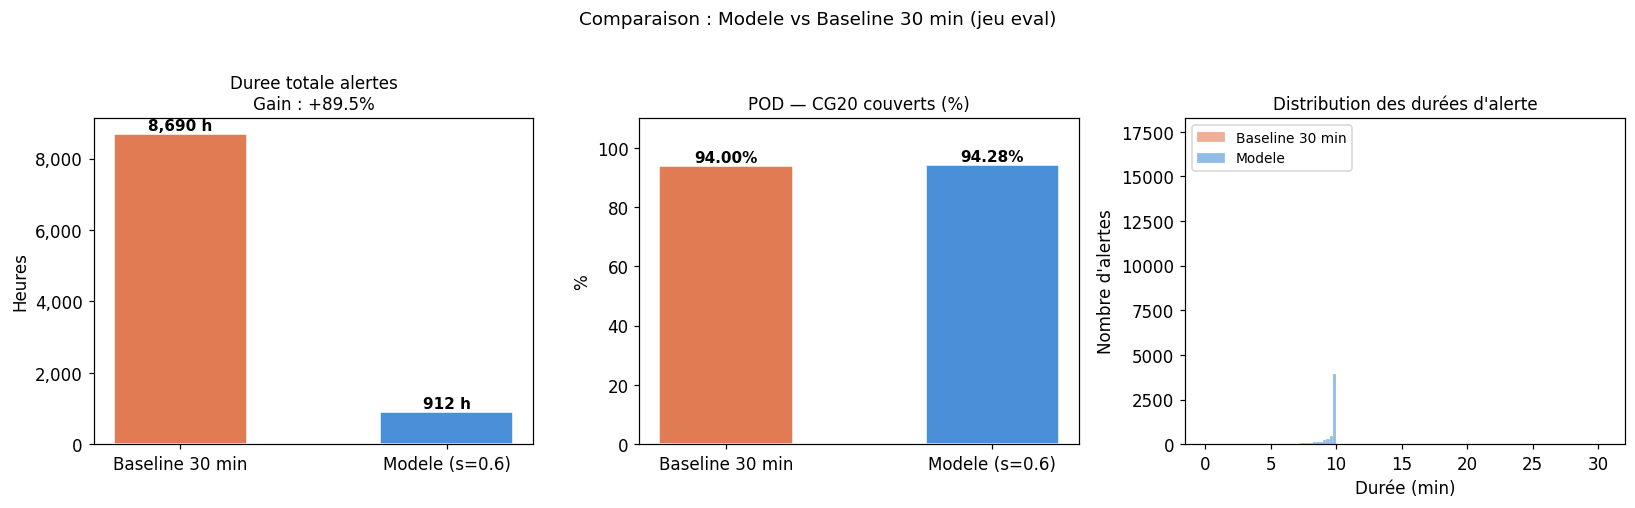

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

colors = ['#e07b54', '#4a90d9']
labels = ['Baseline 30 min', f'Modele (s={SEUIL_OPTIMAL})']

# ── Durée totale ──────────────────────────────────────────────
vals_dur = [row_base['Durée totale (h)'], row_model['Durée totale (h)']]
bars = axes[0].bar(labels, vals_dur, color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals_dur):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + vals_dur[1]*0.01,
                 f'{v:,.0f} h', ha='center', va='bottom', fontsize=10, fontweight='bold')
gain_dur = (vals_dur[0] - vals_dur[1]) / vals_dur[0] * 100
axes[0].set_title(f'Duree totale alertes\nGain : {gain_dur:+.1f}%', fontsize=11)
axes[0].set_ylabel('Heures')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── POD ──────────────────────────────────────────────────────
vals_pod = [row_base['POD (%)'], row_model['POD (%)']]
bars = axes[1].bar(labels, vals_pod, color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals_pod):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('POD — CG20 couverts (%)', fontsize=11)
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 110)

# ── Distribution des durées d'alerte ────────────────────────
axes[2].hist(df_logs_base['duree_min'].clip(0, 120),  bins=40, alpha=0.6,
             color=colors[0], label='Baseline 30 min', edgecolor='white', linewidth=0.2)
axes[2].hist(df_logs_model['duree_min'].clip(0, 120), bins=40, alpha=0.6,
             color=colors[1], label=f'Modele', edgecolor='white', linewidth=0.2)
axes[2].set_title('Distribution des durées d\'alerte', fontsize=11)
axes[2].set_xlabel('Durée (min)')
axes[2].set_ylabel('Nombre d\'alertes')
axes[2].legend(fontsize=9)

plt.suptitle('Comparaison : Modele vs Baseline 30 min (jeu eval)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('comparaison_modele_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

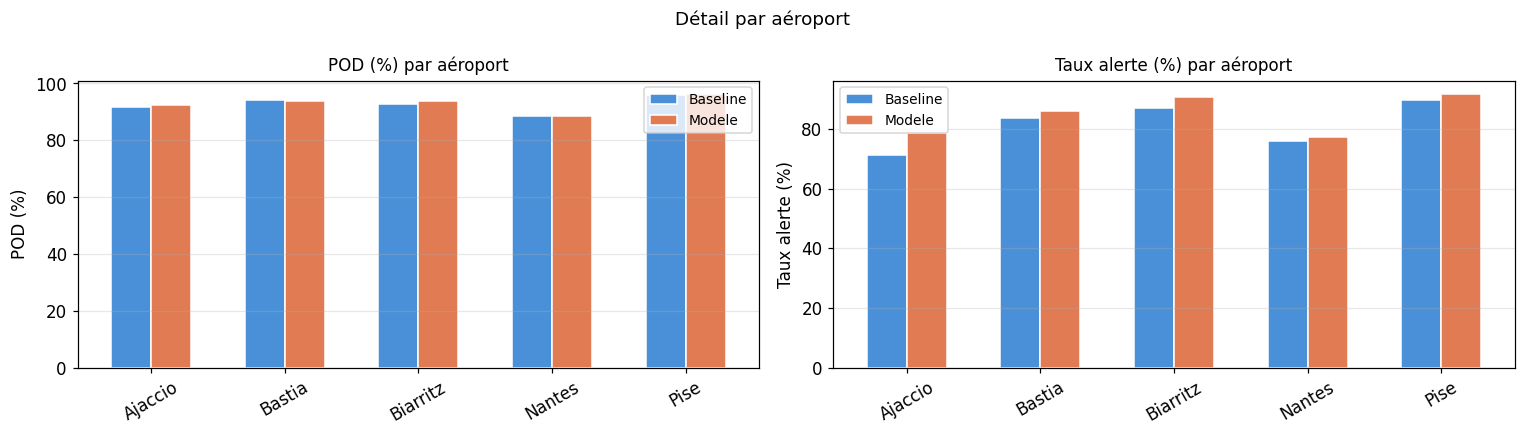

In [12]:
# ── Comparaison par aéroport ──────────────────────────────────
rows = []
for ap in sorted(data['airport'].unique()):
    sub = data[data['airport'] == ap]
    cg20 = (~sub['icloud'].astype(bool)) & (sub['dist'] <= 20)
    for col, label in [('alerte_modele', 'Modele'), ('alerte_baseline', 'Baseline')]:
        pod = (cg20 & (sub[col] == 1)).sum() / cg20.sum() if cg20.sum() > 0 else 0
        taux = sub[col].mean()
        rows.append({'Airport': ap, 'Systeme': label, 'POD (%)': round(pod*100,1), 'Taux alerte (%)': round(taux*100,1)})

df_ap = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric in zip(axes, ['POD (%)', 'Taux alerte (%)']):
    pivot = df_ap.pivot(index='Airport', columns='Systeme', values=metric)
    pivot.plot(kind='bar', ax=ax, color=colors[::-1], edgecolor='white', width=0.6)
    ax.set_title(f'{metric} par aéroport', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Détail par aéroport', fontsize=12)
plt.tight_layout()
plt.savefig('comparaison_par_aeroport.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Bilan energétique

In [13]:
nrj.total()


=== Energie totale : 0.0882 Wh  (0.000088 kWh) ===


---
## 8. Conclusion

### Résumé de l'approche

Nous avons remplacé la règle fixe de 30 minutes par un système adaptatif basé sur 4 modèles XGBoost.  
Le seuil de décision a été optimisé par validation croisée temporelle (5 folds) en minimisant un score combiné :

$$\text{Score}(s) = \frac{\text{Durée}(s) - \min}{\max - \min} + \frac{\text{CG20 manqués}(s) - \min}{\max - \min}$$

### Points forts

- **Anticipation** : le système peut déclencher une alerte *avant* le premier éclair détecté
- **Levée rapide** : si les modèles prédisent une faible activité future, l'alerte est levée plus tôt qu'avec la règle fixe 30 min
- **Adaptabilité** : le seuil unique permet de régler le compromis sécurité / durée d'alerte

### Limitations et pistes d'amélioration

- Les seuils des 4 modèles sont contraints d'être égaux — une optimisation indépendante pourrait apporter un gain supplémentaire
- L'évaluation ne tient pas compte des **fausses alertes** (alertes sans aucun CG20)
- Des features spatio-temporelles plus fines (trajectoire de cellule orageuse) pourraient améliorer les prédictions